In [5]:
import pandas as pd
import yfinance as yf
import talib
import matplotlib.pyplot as plt
import seaborn as sns

# Setup plotting
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

# 1. Define the stock ticker you want to analyze
# (In a full app, you would loop through the unique tickers found in Task 1)
ticker = "AAPL" 

# 2. Fetch Data using YFinance
# valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
stock_data = yf.download(ticker, start="2023-01-01", end="2024-01-01")

# 3. Inspect Data
# Ensure columns: Open, High, Low, Close, Volume exist 
print(stock_data.head())

C:\Users\Her\AppData\Local\Temp\ipykernel_29520\1217846058.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start="2023-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2023-01-03  123.211205  128.954553  122.324579  128.343772  112117500
2023-01-04  124.482040  126.747861  123.221065  125.004162   89113600
2023-01-05  123.161949  125.871079  122.905819  125.240591   80962700
2023-01-06  127.693573  128.353614  123.033875  124.137232   87754700
2023-01-09  128.215683  131.427242  127.959553  128.530934   70790800


In [17]:
# --- Full Corrected Phase 4 Block ---

# 3. CRITICAL: Ensure the 'Close' column is numeric and drop NaNs
# (Assuming the column flattening from the last fix was run successfully)
stock_data['Close'] = pd.to_numeric(stock_data['Close'], errors='coerce')
stock_data.dropna(subset=['Close'], inplace=True)
close_prices = stock_data['Close'].values

# 1. Moving Averages (MA)
# Note: When assigning back, pandas aligns by index. Since we only dropped NaNs, this usually works.
stock_data['SMA_20'] = talib.SMA(close_prices, timeperiod=20)
stock_data['SMA_50'] = talib.SMA(close_prices, timeperiod=50)

# 2. Relative Strength Index (RSI)
stock_data['RSI'] = talib.RSI(close_prices, timeperiod=14)

# 3. MACD (Moving Average Convergence Divergence)
stock_data['MACD'], stock_data['MACD_signal'], stock_data['MACD_hist'] = talib.MACD(
    close_prices, 
    fastperiod=12, 
    slowperiod=26, 
    signalperiod=9
)

# Display the tail to confirm new columns are present
print("\nTechnical Indicators calculated successfully:")
print(stock_data[['Close', 'SMA_20', 'RSI', 'MACD']].tail())


Technical Indicators calculated successfully:
Price            Close      SMA_20        RSI      MACD
Date                                                   
2023-12-22  191.788773  191.856622  54.672819  2.633143
2023-12-26  191.243912  192.018098  53.090039  2.304753
2023-12-27  191.342941  192.154310  53.354355  2.029102
2023-12-28  191.768936  192.362840  54.540953  1.823995
2023-12-29  190.728760  192.490632  51.121303  1.559536


In [18]:
# Calculate RSI
stock_data['RSI'] = talib.RSI(stock_data['Close'], timeperiod=14)

In [19]:
# Calculate MACD
# macd = MACD line, macdsignal = Signal line, macdhist = Histogram
stock_data['MACD'], stock_data['MACD_signal'], stock_data['MACD_hist'] = talib.MACD(
    stock_data['Close'], 
    fastperiod=12, 
    slowperiod=26, 
    signalperiod=9
)

In [20]:
# Example: Calculating Daily Returns manually (standard practice)
stock_data['Daily_Return'] = stock_data['Close'].pct_change()

# Using PyNance (if installed successfully)
# import pynance as pn
# vol = pn.metrics.volatility(stock_data['Close'])

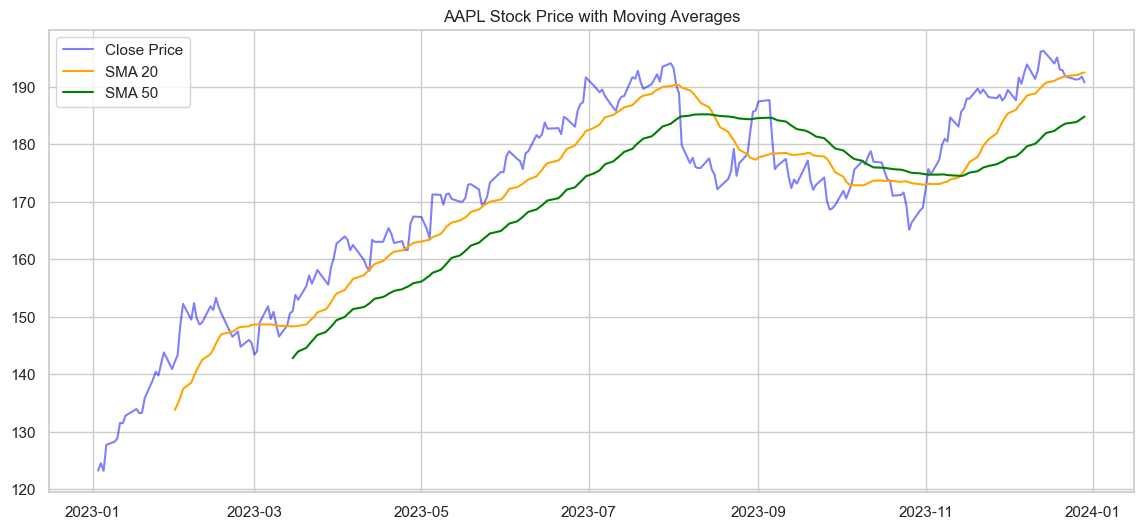

In [21]:
plt.figure(figsize=(14, 6))
plt.plot(stock_data.index, stock_data['Close'], label='Close Price', color='blue', alpha=0.5)
plt.plot(stock_data.index, stock_data['SMA_20'], label='SMA 20', color='orange')
plt.plot(stock_data.index, stock_data['SMA_50'], label='SMA 50', color='green')
plt.title(f'{ticker} Stock Price with Moving Averages')
plt.legend()
plt.show()

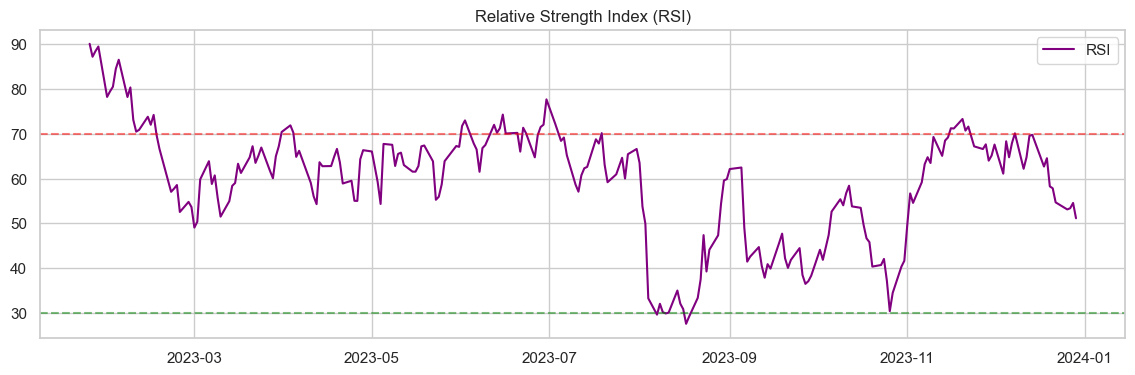

In [22]:
plt.figure(figsize=(14, 4))
plt.plot(stock_data.index, stock_data['RSI'], label='RSI', color='purple')
plt.axhline(70, color='red', linestyle='--', alpha=0.5) # Overbought line
plt.axhline(30, color='green', linestyle='--', alpha=0.5) # Oversold line
plt.title('Relative Strength Index (RSI)')
plt.legend()
plt.show()

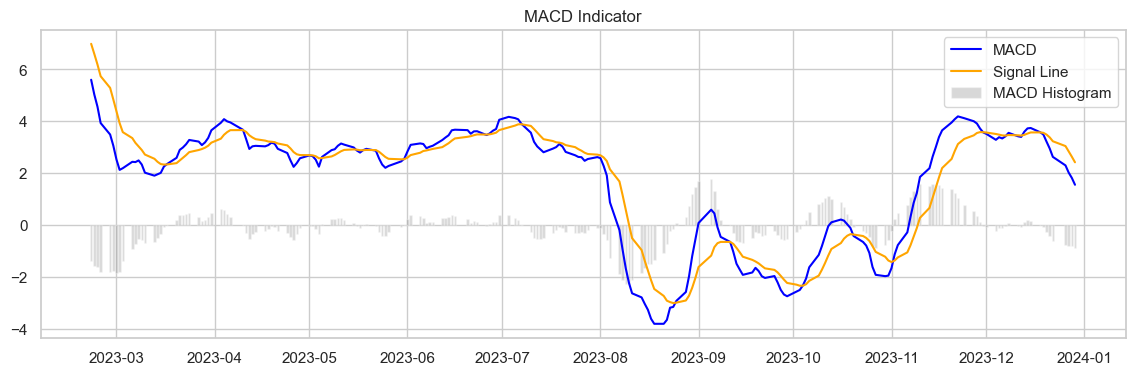

In [23]:
plt.figure(figsize=(14, 4))
plt.plot(stock_data.index, stock_data['MACD'], label='MACD', color='blue')
plt.plot(stock_data.index, stock_data['MACD_signal'], label='Signal Line', color='orange')
plt.bar(stock_data.index, stock_data['MACD_hist'], label='MACD Histogram', color='gray', alpha=0.3)
plt.title('MACD Indicator')
plt.legend()
plt.show()